# 06 · Gymnasium Environments Analysis

Analyses `C2GFastEnv` (5-min, 3-lever) and `C2GMacroEnv` (15-min, 2-lever) under random and heuristic policies across all 4 NeurIPS scenarios.

In [1]:
import sys, os
os.chdir("/lustre/guillant/C2G-Macro")
sys.path.insert(0, ".")
import numpy as np, matplotlib.pyplot as plt
from c2g_env import C2GFastEnv, C2GMacroEnv

SCENARIOS = ["default", "scenario_a", "scenario_b", "scenario_c"]
LABELS    = ["Default", "GenAI Crisis", "Thermal Squeeze", "Battery Drain"]

def rollout_fast(scenario, seed=42, policy="random", n_steps=288):
    env = C2GFastEnv(scenario=scenario)
    obs, _ = env.reset(seed=seed)
    records = []
    for _ in range(n_steps):
        if policy == "random":
            act = env.action_space.sample()
        else:  # safe: full throttle, moderate HVAC, no BESS
            act = np.array([1.0, 0.7, 0.0], dtype=np.float32)
        obs, rew, term, trunc, info = env.step(act)
        records.append(info | {"obs": obs.copy(), "reward": rew})
        if term or trunc:
            break
    return records

print("Environments imported OK.")

Environments imported OK.


## 6.1 Single Episode Rollout — C2GFastEnv (Default, Safe Policy)

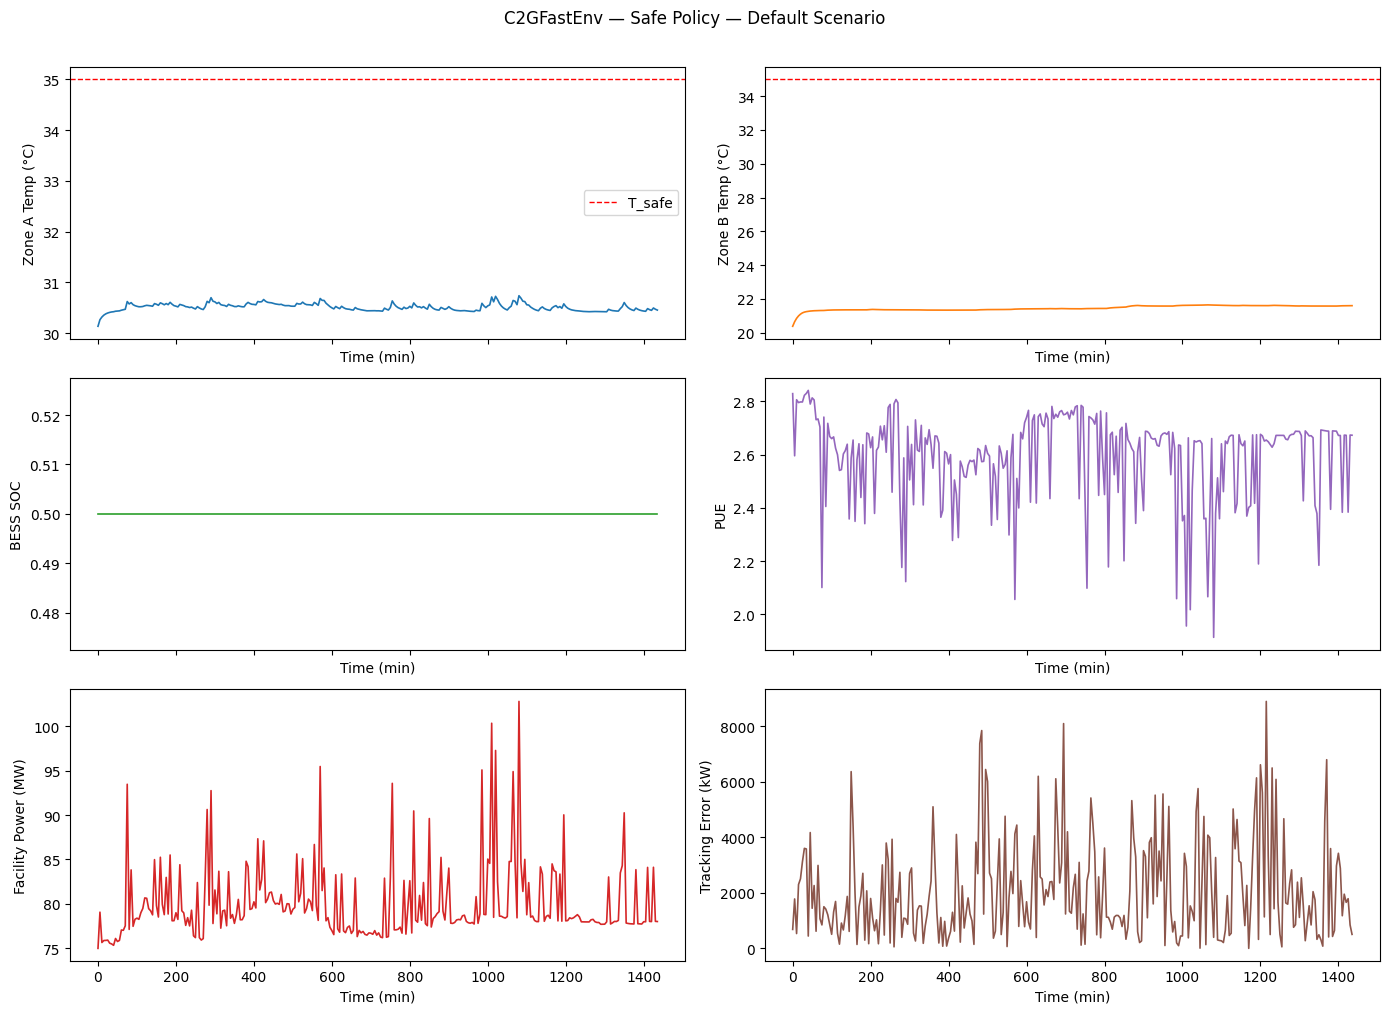

In [2]:
recs = rollout_fast("default", policy="safe")
t   = np.arange(len(recs)) * 5   # minutes

keys = [("temp_A", "Zone A Temp (°C)", "tab:blue"),
        ("temp_B", "Zone B Temp (°C)", "tab:orange"),
        ("bess_soc", "BESS SOC", "tab:green"),
        ("pue", "PUE", "tab:purple"),
        ("p_facility_mw", "Facility Power (MW)", "tab:red"),
        ("tracking_err_kw", "Tracking Error (kW)", "tab:brown")]

fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
for ax, (key, label, color) in zip(axes.flat, keys):
    vals = [r[key] for r in recs]
    ax.plot(t, vals, lw=1.2, color=color)
    if key == "temp_A": ax.axhline(35, color="red", ls="--", lw=1, label="T_safe"); ax.legend()
    if key == "temp_B": ax.axhline(35, color="red", ls="--", lw=1)
    ax.set_ylabel(label); ax.set_xlabel("Time (min)")
plt.suptitle("C2GFastEnv — Safe Policy — Default Scenario", y=1.01)
plt.tight_layout(); plt.savefig("notebooks/fig_fast_rollout.png", dpi=120); plt.show()

## 6.2 Reward Decomposition

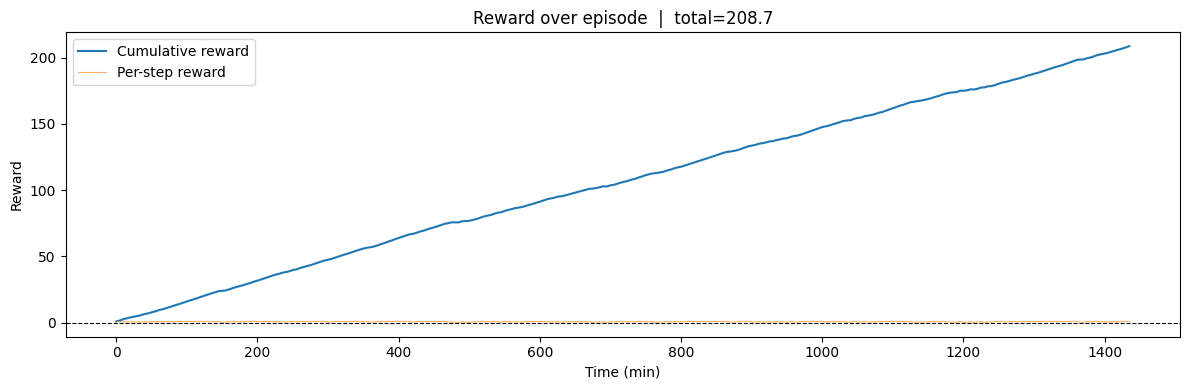

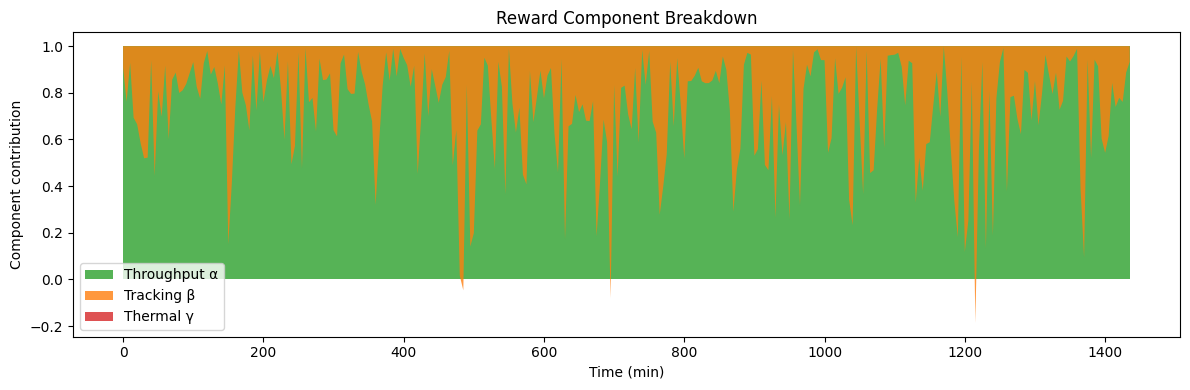

In [3]:
fig, ax = plt.subplots(figsize=(12, 4))
rewards = [r["reward"] for r in recs]
ax.plot(t, np.cumsum(rewards), lw=1.5, label="Cumulative reward")
ax.plot(t, rewards, lw=0.8, alpha=0.6, label="Per-step reward")
ax.axhline(0, color="k", ls="--", lw=0.8)
ax.set_xlabel("Time (min)"); ax.set_ylabel("Reward"); ax.legend()
ax.set_title(f"Reward over episode  |  total={sum(rewards):.1f}")
plt.tight_layout(); plt.savefig("notebooks/fig_fast_reward.png", dpi=120); plt.show()

# Tracking vs thermal components
beta, gamma = 2.0, 5.0
norm_kw = 15_000
track = [-beta * r["tracking_err_kw"] / norm_kw for r in recs]
therm = [-gamma * (max(0, r["temp_A"]-33) + max(0, r["temp_B"]-33)) for r in recs]
through = [1.0] * len(recs)   # safe policy: throttle=1

fig, ax = plt.subplots(figsize=(12, 4))
ax.stackplot(t, [through, track, therm], labels=["Throughput α", "Tracking β", "Thermal γ"],
             colors=["tab:green", "tab:orange", "tab:red"], alpha=0.8)
ax.set_xlabel("Time (min)"); ax.set_ylabel("Component contribution")
ax.set_title("Reward Component Breakdown"); ax.legend(loc="lower left")
plt.tight_layout(); plt.savefig("notebooks/fig_fast_components.png", dpi=120); plt.show()

## 6.3 Scenario Comparison — All 4 NeurIPS Scenarios

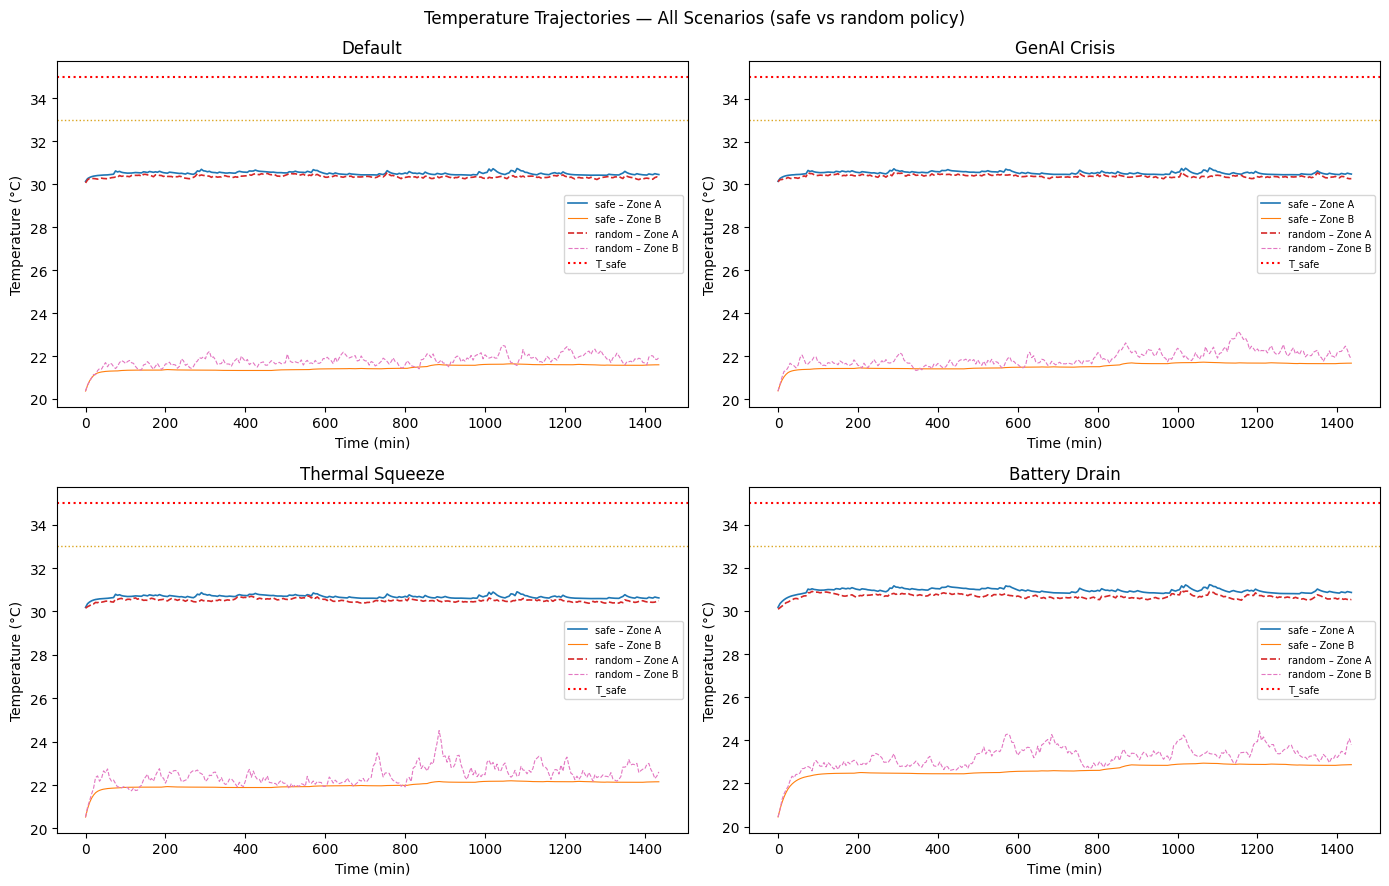

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes_flat = axes.flat

for sc, label in zip(SCENARIOS, LABELS):
    ax = next(axes_flat)
    for policy, color, ls in [("safe","tab:blue","-"), ("random","tab:red","--")]:
        recs_sc = rollout_fast(sc, seed=0, policy=policy)
        t_sc = np.arange(len(recs_sc)) * 5
        ta = [r["temp_A"] for r in recs_sc]
        tb = [r["temp_B"] for r in recs_sc]
        ax.plot(t_sc, ta, color=color, ls=ls, lw=1.2,
                label=f"{policy} – Zone A")
        ax.plot(t_sc, tb, color="tab:orange" if color=="tab:blue" else "tab:pink",
                ls=ls, lw=0.8, label=f"{policy} – Zone B")
    ax.axhline(35, color="red", ls=":", lw=1.5, label="T_safe")
    ax.axhline(33, color="goldenrod", ls=":", lw=1)
    ax.set_title(label); ax.set_xlabel("Time (min)"); ax.set_ylabel("Temperature (°C)")
    ax.legend(fontsize=7)
plt.suptitle("Temperature Trajectories — All Scenarios (safe vs random policy)")
plt.tight_layout(); plt.savefig("notebooks/fig_scenarios_temp.png", dpi=120); plt.show()

## 6.4 Observation Space Coverage

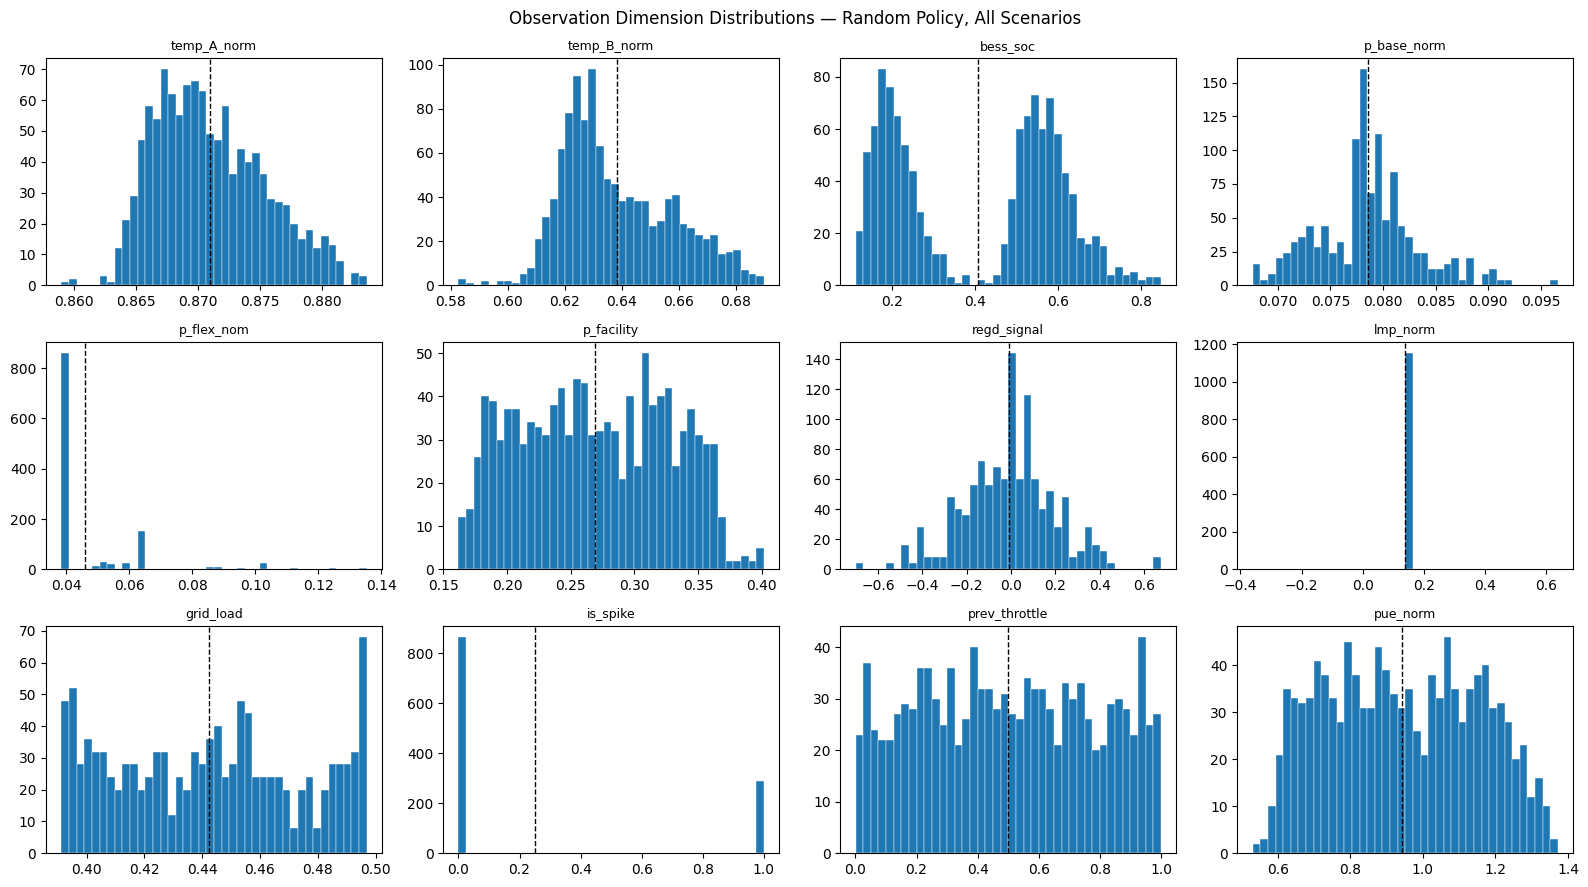

In [5]:
# Gather observations across all scenarios
all_obs = []
for sc in SCENARIOS:
    recs_sc = rollout_fast(sc, seed=0, policy="random")
    all_obs.extend([r["obs"] for r in recs_sc])
all_obs = np.array(all_obs)

obs_names = ["temp_A_norm","temp_B_norm","bess_soc","p_base_norm",
             "p_flex_nom","p_facility","regd_signal","lmp_norm",
             "grid_load","is_spike","prev_throttle","pue_norm"]

fig, axes = plt.subplots(3, 4, figsize=(16, 9))
for i, (ax, name) in enumerate(zip(axes.flat, obs_names)):
    ax.hist(all_obs[:, i], bins=40, edgecolor="white", lw=0.3)
    ax.set_title(name, fontsize=9)
    ax.axvline(all_obs[:, i].mean(), color="k", ls="--", lw=1)
plt.suptitle("Observation Dimension Distributions — Random Policy, All Scenarios")
plt.tight_layout(); plt.savefig("notebooks/fig_obs_coverage.png", dpi=120); plt.show()

## 6.5 C2GMacroEnv — Macro Episode Rollout

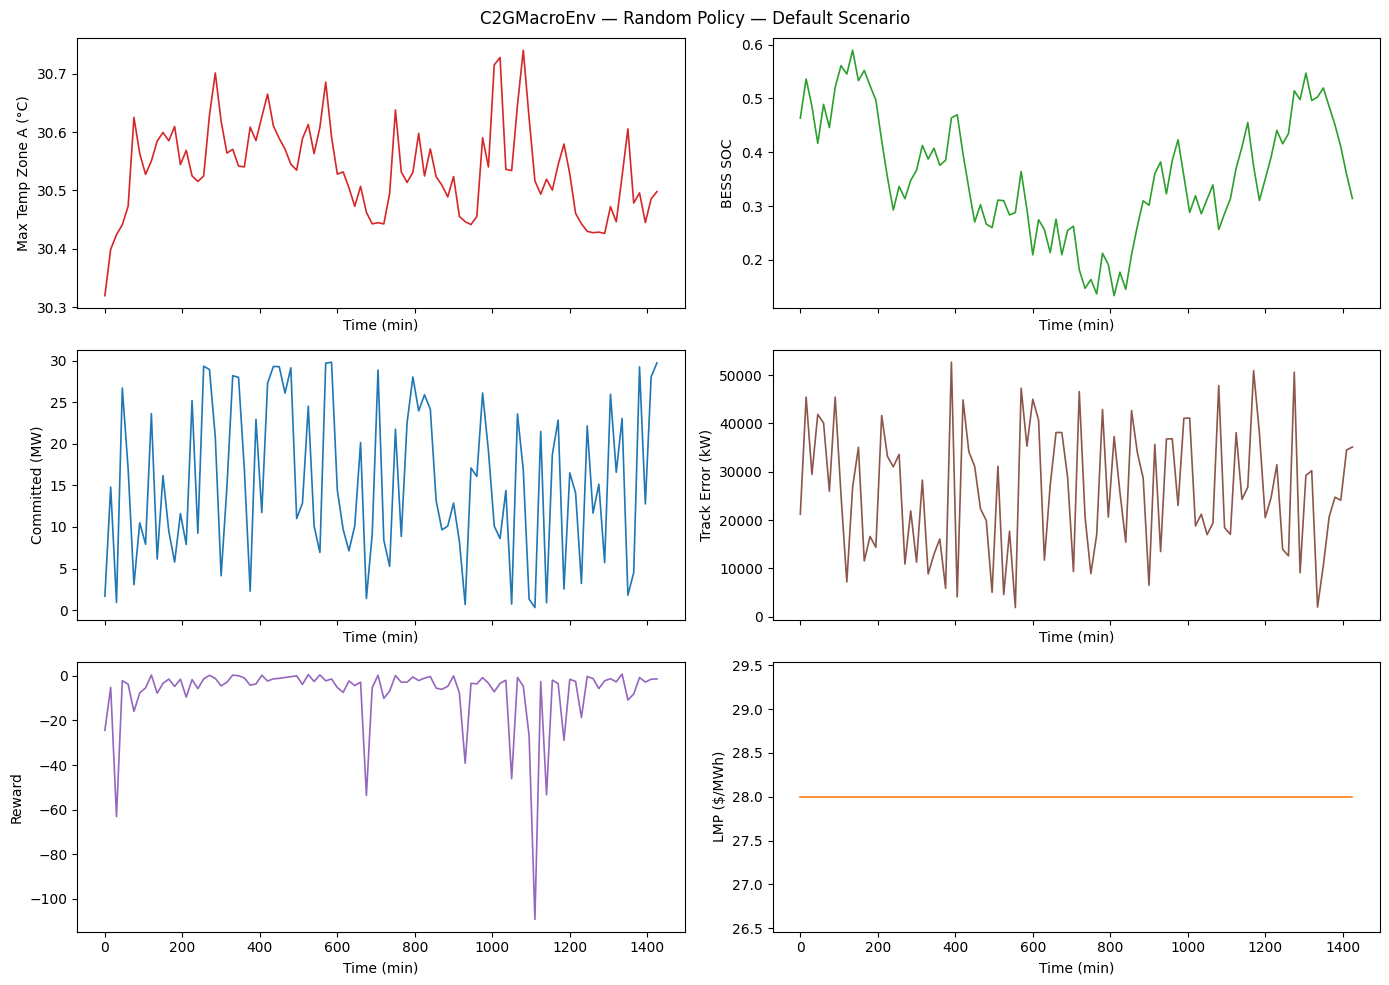

Macro episode: 96 steps  |  total reward: -726.95


In [6]:
def rollout_macro(scenario, seed=42, n_steps=96):
    env = C2GMacroEnv(scenario=scenario)
    obs, _ = env.reset(seed=seed)
    records = []
    for _ in range(n_steps):
        act = env.action_space.sample()
        obs, rew, term, trunc, info = env.step(act)
        records.append({
            "reward":      rew,
            "committed":   info["committed_mw"],
            "track_err":   info["mean_tracking_err"],
            "temp_A_max":  info["temp_A_max"],
            "temp_B_max":  info["temp_B_max"],
            "bess_soc":    info["bess_soc_end"],
            "mean_lmp":    info["mean_lmp"],
        })
        if term or trunc: break
    return records

mrecs = rollout_macro("default", seed=0)
t_mac = np.arange(len(mrecs)) * 15  # minutes

fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
for ax, key, label, color in zip(axes.flat,
        ["temp_A_max","bess_soc","committed","track_err","reward","mean_lmp"],
        ["Max Temp Zone A (°C)","BESS SOC","Committed (MW)","Track Error (kW)","Reward","LMP ($/MWh)"],
        ["tab:red","tab:green","tab:blue","tab:brown","tab:purple","tab:orange"]):
    vals = [r[key] for r in mrecs]
    ax.plot(t_mac, vals, lw=1.2, color=color)
    ax.set_ylabel(label); ax.set_xlabel("Time (min)")
plt.suptitle("C2GMacroEnv — Random Policy — Default Scenario")
plt.tight_layout(); plt.savefig("notebooks/fig_macro_rollout.png", dpi=120); plt.show()
print(f"Macro episode: {len(mrecs)} steps  |  total reward: {sum(r['reward'] for r in mrecs):.2f}")

## 6.6 Scenario Reward Summary

       Scenario Policy  Total Reward  Thermal Faults  Max Temp A  Max Temp B  Steps
        Default   safe        198.34               0        30.7        21.6    288
        Default random       -792.28               0        30.6        22.5    288
   GenAI Crisis   safe        198.34               0        30.8        21.7    288
   GenAI Crisis random       -587.70               0        30.6        22.6    288
Thermal Squeeze   safe        198.34               0        30.9        22.2    288
Thermal Squeeze random       -331.59               0        30.7        24.6    288
  Battery Drain   safe        198.34               0        31.2        22.9    288
  Battery Drain random       -595.96               0        31.0        24.2    288


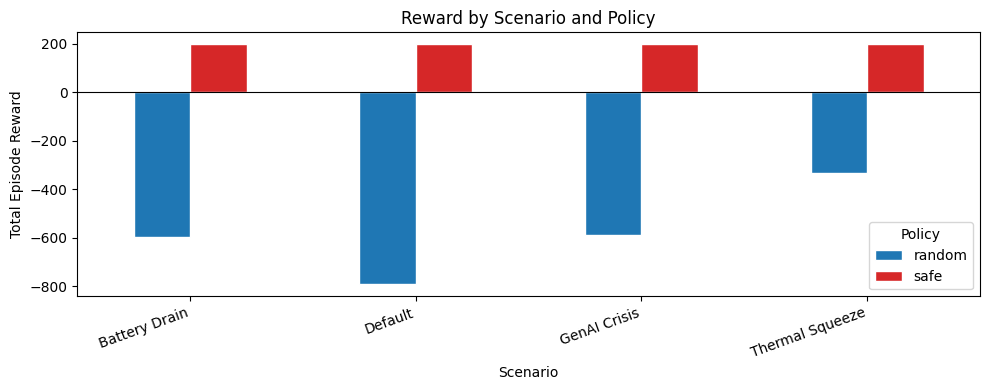

In [7]:
import pandas as pd

summary = []
for sc, label in zip(SCENARIOS, LABELS):
    for policy in ["safe", "random"]:
        recs_sc = rollout_fast(sc, seed=0, policy=policy)
        total_r = sum(r["reward"] for r in recs_sc)
        n_term  = sum(1 for r in recs_sc if r["thermal_terminated"])
        max_TA  = max(r["temp_A"] for r in recs_sc)
        max_TB  = max(r["temp_B"] for r in recs_sc)
        summary.append({"Scenario": label, "Policy": policy,
                         "Total Reward": round(total_r, 2),
                         "Thermal Faults": n_term,
                         "Max Temp A": round(max_TA, 1),
                         "Max Temp B": round(max_TB, 1),
                         "Steps": len(recs_sc)})

df = pd.DataFrame(summary)
print(df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
df_pivot = df.pivot(index="Scenario", columns="Policy", values="Total Reward")
df_pivot.plot(kind="bar", ax=ax, color=["tab:blue", "tab:red"], edgecolor="white")
ax.set_ylabel("Total Episode Reward"); ax.set_title("Reward by Scenario and Policy")
ax.axhline(0, color="k", lw=0.8); plt.xticks(rotation=20, ha="right")
plt.tight_layout(); plt.savefig("notebooks/fig_scenario_rewards.png", dpi=120); plt.show()